In [1]:
# Import data analysis libraries
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset from data folder
df = pd.read_csv("../data/raw/loan_default_dataset_noisy.csv")

# Preview first 5 rows
df.head()


,CustomerID,Age,Gender,Marital_Status,Education,Employment_Type,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Income_Loan_Ratio,Loan_Status
0,1000,59,Male,Single,Not Graduate,Salaried,11082,3363,284.0,120,1.0,Semiurban,0.508627,Y
1,1001,49,NaN,Married,Graduate,Salaried,10822,3524,164.0,360,0.0,Semiurban,0.874756,Y
2,1002,35,Male,Married,Graduate,Salaried,3986,3786,414.0,240,1.0,Semiurban,0.187729,N
3,1003,63,Male,Single,Not Graduate,Salaried,10526,23,139.0,300,1.0,Rural,0.758921,Y
4,1004,28,Female,Married,Graduate,Salaried,9918,3003,257.0,240,0.0,Urban,0.502763,N


In [4]:
# Summary statistics for numerical columns
df.describe()


,CustomerID,Age,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Income_Loan_Ratio
count,2100.000000,2100.000000,2100.000000,2100.000000,1994.000000,2100.000000,1993.000000,2100.000000
mean,2001.513810,42.670000,8290.765238,4049.764762,270.344534,240.571429,0.792775,0.640285
std,578.359094,12.603574,3912.710716,2288.544407,128.411200,85.535374,0.405420,0.547168
min,1000.000000,21.000000,1512.000000,2.000000,50.000000,120.000000,0.000000,0.047368
25%,1499.750000,32.000000,4910.750000,2067.250000,158.250000,180.000000,1.000000,0.297800
50%,2002.500000,43.000000,8367.500000,4050.500000,271.000000,240.000000,1.000000,0.457574
75%,2503.250000,54.000000,11666.000000,6001.250000,379.000000,300.000000,1.000000,0.772765
max,2999.000000,64.000000,14999.000000,7999.000000,499.000000,360.000000,1.000000,4.034510


In [5]:
# Count missing values per column
df.isnull().sum()


CustomerID             0
Age                    0
Gender               105
Marital_Status       107
Education              0
Employment_Type        0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount           106
Loan_Amount_Term       0
Credit_History       107
Property_Area          0
Income_Loan_Ratio      0
Loan_Status            0
dtype: int64

In [7]:
# Count duplicate rows
df.duplicated().sum()


np.int64(100)

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()


In [9]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [10]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Marital_Status"] = df["Marital_Status"].fillna(df["Marital_Status"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])



In [11]:
df.columns = df.columns.str.strip()

In [12]:
# Fix column names (remove spaces)
df.columns = df.columns.str.strip()

# Identify text columns
text_columns = df.select_dtypes(include=["object", "string"]).columns

# Standardise text (lowercase + remove spaces)
for col in text_columns:
    df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)

# Convert selected columns to title case for readability
cols_to_title = ["Gender", "Marital_Status", "Education", "Employment_Type", "Property_Area"]

for col in cols_to_title:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x)



In [13]:
# Check values before mapping
print(df["Loan_Status"].unique())

# Convert to numeric (after cleaning → values are lowercase)
df["Loan_Status"] = df["Loan_Status"].map({"y": 1, "n": 0})

# Verify conversion
df["Loan_Status"].value_counts()

#Take Screenshot: 11. Conver Loan Status to Numeric

<StringArray>
['y', 'n']
Length: 2, dtype: str


Loan_Status
1    1040
0     960
Name: count, dtype: int64

In [14]:
# Create total income
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

# Create loan-to-income ratio
df["Loan_Income_Ratio"] = df["LoanAmount"] / df["Total_Income"]

#Take Screenshot: 12. Create New Columns
________________________________________
# Preview cleaned dataset
df.head()

#Take Screenshot: 13. Preview Cleaned Dataset
________________________________________

# Final check of cleaned data
df.info()

#Take Screenshot: 14. Final Checks of Cleaned Data


# Save cleaned dataset to new CSV file
df.to_csv("../data/cleaned_data/loan_default_dataset_cleaned.csv", index=False)



NameError: name '________________________________________' is not defined

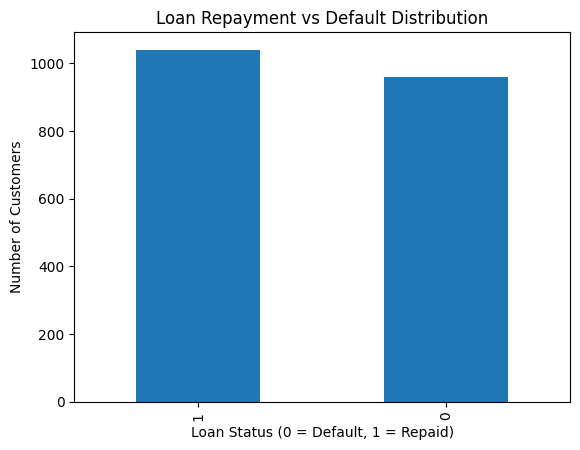

In [15]:
#Loan Default Distribution
df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Repayment vs Default Distribution")
plt.xlabel("Loan Status (0 = Default, 1 = Repaid)")
plt.ylabel("Number of Customers")

# plt.savefig("../images/09_default_distribution.png")
plt.show()



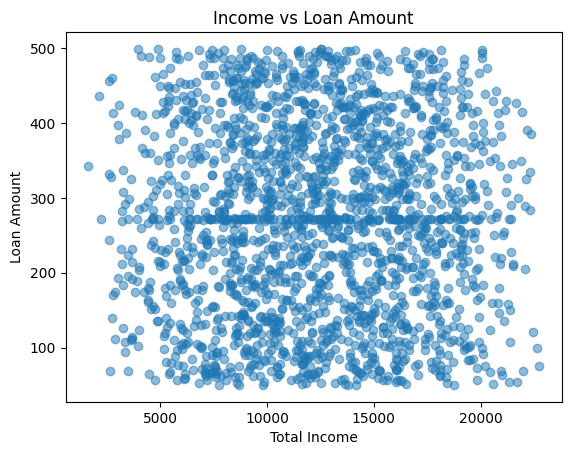

In [16]:
#Income vs Loan Amount
plt.scatter(df["Total_Income"], df["LoanAmount"], alpha=0.5)

plt.title("Income vs Loan Amount")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")

#plt.savefig("../images/10_income_vs_loan.png")
plt.show()


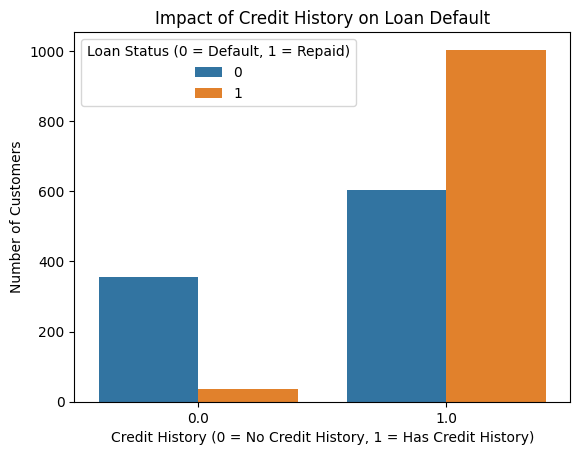

In [17]:
#Credit History vs Default
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)

plt.title("Impact of Credit History on Loan Default")
plt.xlabel("Credit History (0 = No Credit History, 1 = Has Credit History)")
plt.ylabel("Number of Customers")

plt.legend(title="Loan Status (0 = Default, 1 = Repaid)")

# plt.savefig("../images/11_credit_vs_default.png")
plt.show()


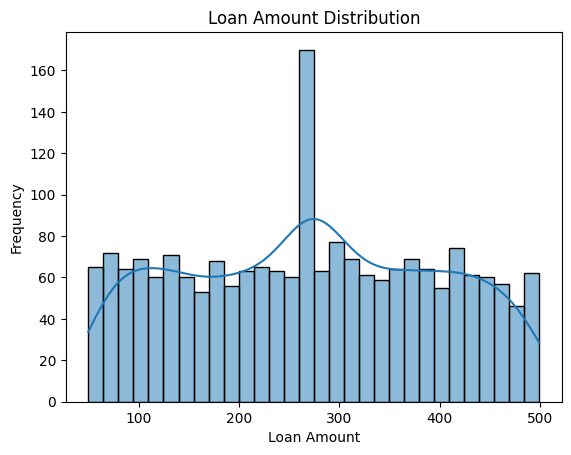

In [21]:
#Loan Amount Distribution (Seaborn)
sns.histplot(df["LoanAmount"], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

#plt.fig("../images/12_loan_distribution.png")
plt.show()



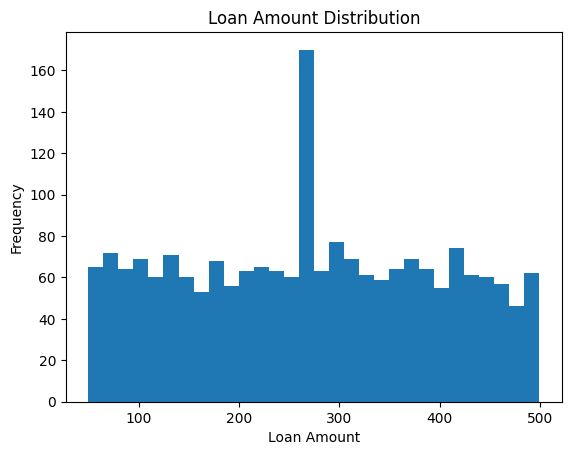

In [22]:
# Using Matplotlib only for Chart 4 (without KDE)

# Chart 4 — Loan Amount Distribution (Matplotlib only)
plt.hist(df["LoanAmount"], bins=30)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

# plt.savefig("../images/12_loan_distribution.png")
plt.show()


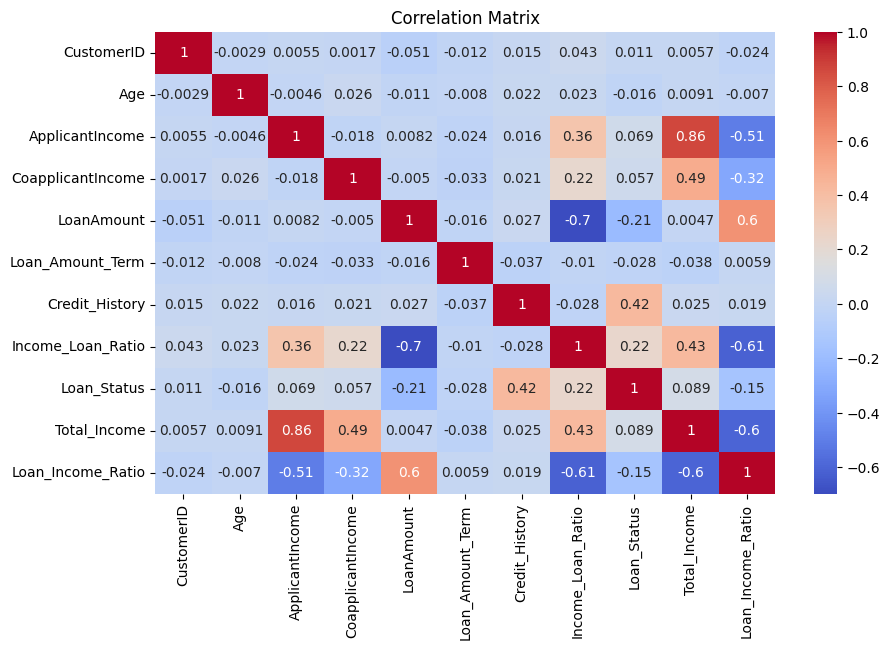

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

# plt.savefig("../images/13_correlation_matrix.png")
plt.show()


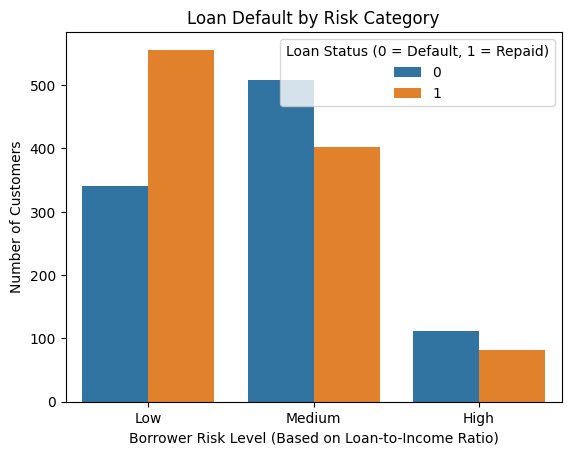

In [26]:
#RISK SEGMENTATION (ADVANCED)
df["Risk_Level"] = pd.cut(
    df["Loan_Income_Ratio"],
    bins=[0, 0.02, 0.05, 1],
    labels=["Low", "Medium", "High"]
)

sns.countplot(x="Risk_Level", hue="Loan_Status", data=df)

plt.title("Loan Default by Risk Category")
plt.xlabel("Borrower Risk Level (Based on Loan-to-Income Ratio)")
plt.ylabel("Number of Customers")

plt.legend(title="Loan Status (0 = Default, 1 = Repaid)")

# plt.savefig("../images/14_risk_segmentation.png")
plt.show()

